In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from scipy import stats

### Part A

In [4]:
def simulation_single(T, rho=0.5, alpha=[0.5, 1], delta=[0.5, -0.5], gamma=[0.5, 1], beta=[-0.5, 0, 0]):
    
    # Initialize separate arrays for each variable
    x = np.zeros(T)
    y = np.zeros(T)
    u = np.zeros(T)
    
    # Initial lags set to zero as specified
    x_lag1 = 0.0
    x_lag2 = 0.0
    u_lag1 = 0.0    # not specified?
    
    # Simulate time series
    for t in range(T):
        # Generate random shocks at each time period, though not specified?
        wt = np.random.normal(0, 1)
        vt = np.random.normal(0, 1)
        
        # Equations
        u[t] = rho * u_lag1 + vt
        x[t] = alpha[0] + alpha[1] * t + delta[0] * x_lag1 + delta[1] * x_lag2 + wt
        y[t] = gamma[0] + gamma[1] * t + beta[0] * x[t] + beta[1] * x_lag1 + beta[2] * x_lag2 + u[t]
        
        # Update lags for next iteration
        x_lag2 = x_lag1
        x_lag1 = x[t]
        u_lag1 = u[t]
    
    # Construct design matrix X with intercept, time, and lags
    intercept = np.ones(T)
    time = np.arange(T)
    x_lag1_vec = np.concatenate([[0], x[:-1]])  # x_{t-1}: shift by 1
    x_lag2_vec = np.concatenate([[0, 0], x[:-2]])  # x_{t-2}: shift by 2
    
    X = np.column_stack([intercept, time, x, x_lag1_vec, x_lag2_vec])
    
    return y, X, u

def simulation_panel(S, T, rho=0.5, alpha=[0.5, 1], delta=[0.5, -0.5], gamma=[0.5, 1], beta=[-0.5, 0, 0]):
    # Initialize arrays to hold the panel data
    Y = np.zeros((S, T))
    X = np.zeros((S, T, 5))  # 5 columns: intercept, time, x_t, x_{t-1}, x_{t-2}
    U = np.zeros((S, T))
    
    for s in range(S):
        y_s, X_s, u_s = simulation_single(T, rho, alpha, delta, gamma, beta)
        Y[s, :] = y_s
        X[s, :, :] = X_s
        U[s, :] = u_s
    
    return Y, X, U

### Part B

Under the baseline parameters, this is a <b>Distributed Lag Model (DLM)</b> with a time trend and several lagged explanatory variables.

The error term u_t follows a <b>First-Order Autoregressive Process</b> as only one lagged explanatory variable is used in the regression.

### Part C

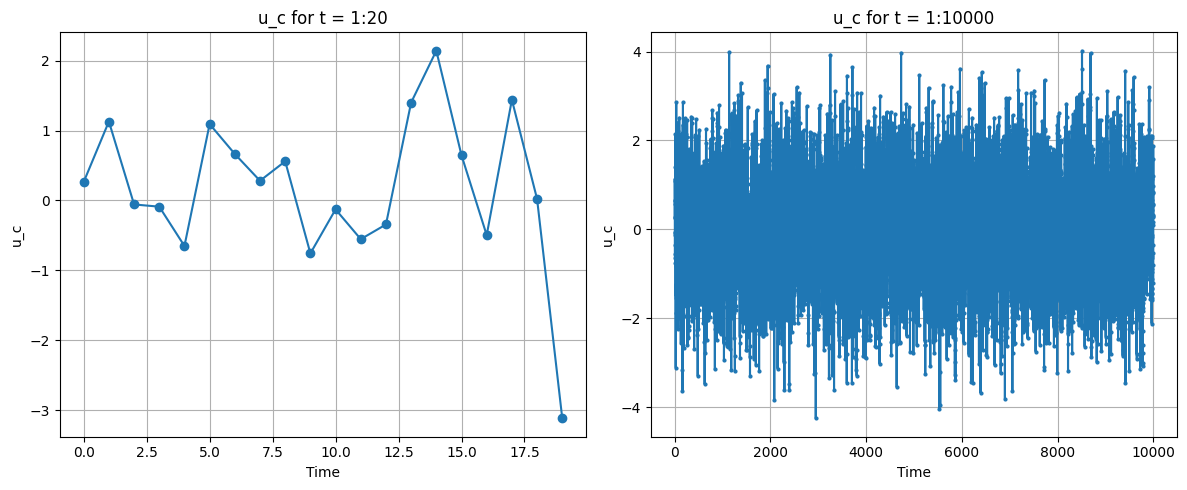

In [5]:
y_c, X_c, u_c = simulation_single(T=10000)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(u_c[:20], marker='o')
plt.title('u_c for t = 1:20')
plt.xlabel('Time')
plt.ylabel('u_c')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(u_c, marker='o', markersize=2)
plt.title('u_c for t = 1:10000')
plt.xlabel('Time')
plt.ylabel('u_c')
plt.grid()
plt.tight_layout()
plt.show()

The data does not look to be very stable from t = 1:20 but deos apear to level out around u_c = 0 over many time periods, similar to a normal function at mean = 0.

### Part D

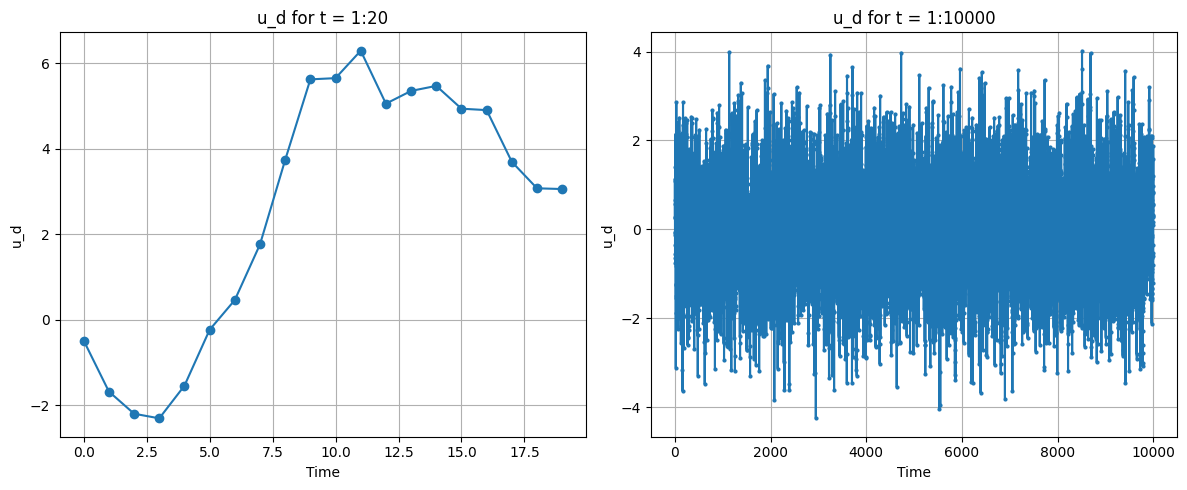

In [6]:
y_d, X_d, u_d = simulation_single(T=10000, rho=1.0)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(u_d[:20], marker='o')
plt.title('u_d for t = 1:20')
plt.xlabel('Time')
plt.ylabel('u_d')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(u_c, marker='o', markersize=2)
plt.title('u_d for t = 1:10000')
plt.xlabel('Time')
plt.ylabel('u_d')
plt.grid()
plt.tight_layout()
plt.show()

### Part E

While the time series results with t = 1:10000 appears relatively the same in both c and, which is expected considering the simulation is modeled to follow a normal function in the long term, the short-term simulation t = 1:20 is different.

### Part F

In [8]:
S, T = 100, 100

Y = np.zeros((S, T))
X = np.zeros((S, T, 5))  # 5 columns: intercept, time, x_t, x_{t-1}, x_{t-2}
U = np.zeros((S, T))
estimates_f = np.zeros((S, 5))  # To store estimates for each simulation

for s in range(S):
    y_s, X_s, u_s = simulation_single(T)
    Y[s, :] = y_s
    X[s, :, :] = X_s
    U[s, :] = u_s

    model = sm.OLS(y_s, X_s)
    results = model.fit()
    estimates_f[s, :] = results.params

print("\nAverage coefficient estimates across simulations:")
print(f"Intercept (γ0): {estimates_f[:, 0].mean():>10.4f}  (True: 0.5000)")
print(f"Time (γ1):      {estimates_f[:, 1].mean():>10.4f}  (True: 1.0000)")
print(f"x_t (β0):       {estimates_f[:, 2].mean():>10.4f}  (True: -0.5000)")
print(f"x_{{t-1}} (β1):   {estimates_f[:, 3].mean():>10.4f}  (True: 0.0000)")
print(f"x_{{t-2}} (β2):   {estimates_f[:, 4].mean():>10.4f}  (True: 0.0000)")

print("\nStandard deviation of estimates:")
print(f"Intercept (γ0): {estimates_f[:, 0].std():>10.4f}")
print(f"Time (γ1):      {estimates_f[:, 1].std():>10.4f}")
print(f"x_t (β0):       {estimates_f[:, 2].std():>10.4f}")
print(f"x_{{t-1}} (β1):   {estimates_f[:, 3].std():>10.4f}")
print(f"x_{{t-2}} (β2):   {estimates_f[:, 4].std():>10.4f}")

# Focus on β0 as requested
beta0_mean_f = estimates_f[:, 2].mean()
beta0_std_f = estimates_f[:, 2].std()

print(f"\n{'='*50}")
print(f"FOCUS ON β0 (coefficient on x_t):")
print(f"Mean of β0 estimates:  {beta0_mean_f:.4f}")
print(f"Std dev of β0 estimates: {beta0_std_f:.4f}")
print(f"True value of β0:       -0.5000")
print(f"{'='*50}")


Average coefficient estimates across simulations:
Intercept (γ0):     0.4699  (True: 0.5000)
Time (γ1):          0.9886  (True: 1.0000)
x_t (β0):          -0.4889  (True: -0.5000)
x_{t-1} (β1):       0.0071  (True: 0.0000)
x_{t-2} (β2):      -0.0069  (True: 0.0000)

Standard deviation of estimates:
Intercept (γ0):     0.3861
Time (γ1):          0.2176
x_t (β0):           0.1243
x_{t-1} (β1):       0.0848
x_{t-2} (β2):       0.1193

FOCUS ON β0 (coefficient on x_t):
Mean of β0 estimates:  -0.4889
Std dev of β0 estimates: 0.1243
True value of β0:       -0.5000


### Part G


------------------------------------------------------------
Simulating with ρ = 0.0
------------------------------------------------------------

Coefficient estimates for β0:
  Mean:        -0.4912
  Std Dev:      0.1021
  Bias:         0.0088
  Min:         -0.7544
  Max:         -0.2653

------------------------------------------------------------
Simulating with ρ = 0.5
------------------------------------------------------------

Coefficient estimates for β0:
  Mean:        -0.5046
  Std Dev:      0.1199
  Bias:        -0.0046
  Min:         -0.7592
  Max:         -0.1621

------------------------------------------------------------
Simulating with ρ = 1.0
------------------------------------------------------------

Coefficient estimates for β0:
  Mean:        -0.5588
  Std Dev:      0.2825
  Bias:        -0.0588
  Min:         -1.6607
  Max:          0.1887

SUMMARY TABLE: β0 Estimates Across Different ρ Values

Statistic            ρ = 0.0         ρ = 0.5         ρ = 1.0     

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/part_g_beta0_distributions.png'

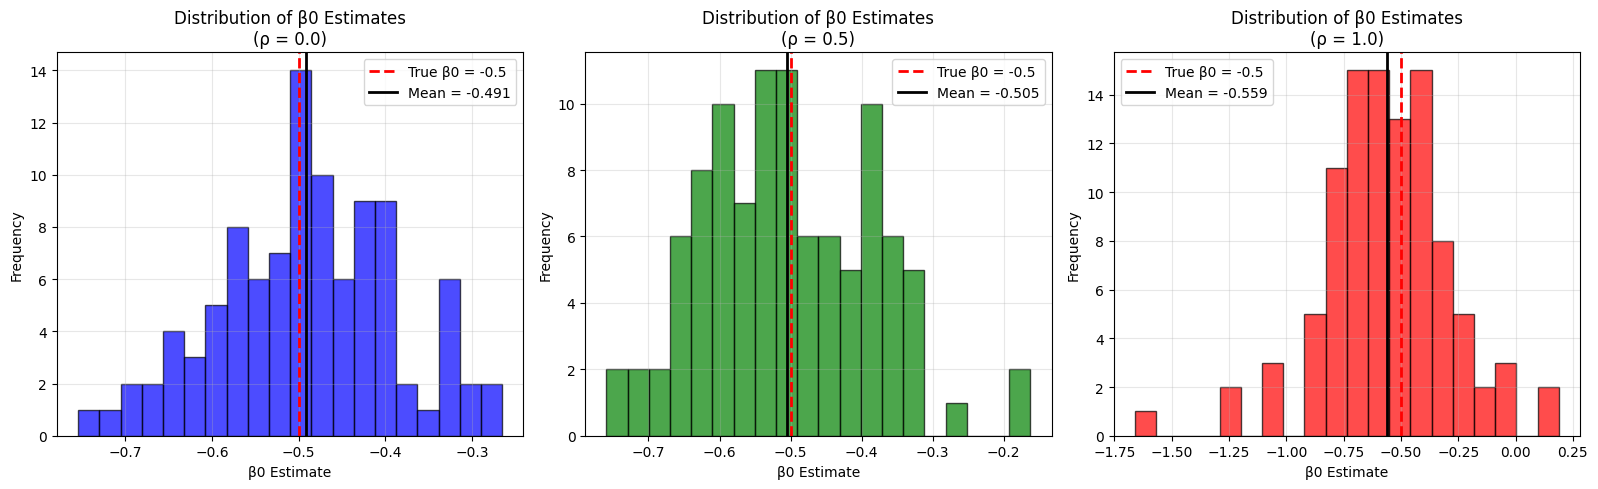

In [14]:
rho_values = [0.0, 0.5, 1.0]
results_dict = {}

for rho in rho_values:
    print(f"\n{'-'*60}")
    print(f"Simulating with ρ = {rho}")
    print(f"{'-'*60}")
    
    estimates = np.zeros((S, 5))
    
    for s in range(S):
        y_s, X_s, u_s = simulation_single(T, rho=rho)
        model = sm.OLS(y_s, X_s)
        results_model = model.fit()
        estimates[s, :] = results_model.params
    
    # Store results
    results_dict[rho] = {
        'estimates': estimates,
        'beta0_mean': estimates[:, 2].mean(),
        'beta0_std': estimates[:, 2].std(),
        'beta0_bias': estimates[:, 2].mean() - (-0.5),
    }
    
    print(f"\nCoefficient estimates for β0:")
    print(f"  Mean:     {estimates[:, 2].mean():>10.4f}")
    print(f"  Std Dev:  {estimates[:, 2].std():>10.4f}")
    print(f"  Bias:     {estimates[:, 2].mean() - (-0.5):>10.4f}")
    print(f"  Min:      {estimates[:, 2].min():>10.4f}")
    print(f"  Max:      {estimates[:, 2].max():>10.4f}")

# Create comparison table
print("\n" + "=" * 80)
print("SUMMARY TABLE: β0 Estimates Across Different ρ Values")
print("=" * 80)
print(f"\n{'Statistic':<20} {'ρ = 0.0':<15} {'ρ = 0.5':<15} {'ρ = 1.0':<15}")
print(f"{'-'*65}")
print(f"{'Mean':<20} {results_dict[0.0]['beta0_mean']:>14.4f} "
      f"{results_dict[0.5]['beta0_mean']:>14.4f} {results_dict[1.0]['beta0_mean']:>14.4f}")
print(f"{'Std Deviation':<20} {results_dict[0.0]['beta0_std']:>14.4f} "
      f"{results_dict[0.5]['beta0_std']:>14.4f} {results_dict[1.0]['beta0_std']:>14.4f}")
print(f"{'Bias':<20} {results_dict[0.0]['beta0_bias']:>14.4f} "
      f"{results_dict[0.5]['beta0_bias']:>14.4f} {results_dict[1.0]['beta0_bias']:>14.4f}")
print(f"{'-'*65}")
print(f"{'True β0 value:':<20} {-0.5:>14.4f}")

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['blue', 'green', 'red']
for idx, rho in enumerate(rho_values):
    estimates = results_dict[rho]['estimates'][:, 2]
    
    axes[idx].hist(estimates, bins=20, alpha=0.7, color=colors[idx], edgecolor='black')
    axes[idx].axvline(x=-0.5, color='red', linestyle='--', linewidth=2, label='True β0 = -0.5')
    axes[idx].axvline(x=results_dict[rho]['beta0_mean'], color='black', 
                     linestyle='-', linewidth=2, label=f"Mean = {results_dict[rho]['beta0_mean']:.3f}")
    axes[idx].set_title(f'Distribution of β0 Estimates\n(ρ = {rho})', fontsize=12)
    axes[idx].set_xlabel('β0 Estimate', fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/part_g_beta0_distributions.png', dpi=300, bbox_inches='tight')
print("\nSaved plot: part_g_beta0_distributions.png")
plt.close()

# Box plot comparison
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [results_dict[rho]['estimates'][:, 2] for rho in rho_values]
bp = ax.boxplot(data_to_plot, labels=[f'ρ = {rho}' for rho in rho_values], 
                patch_artist=True)

# Color the boxes
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=-0.5, color='red', linestyle='--', linewidth=2, label='True β0 = -0.5')
ax.set_ylabel('β0 Estimate', fontsize=12)
ax.set_title('Comparison of β0 Estimates Across Different ρ Values', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/part_g_beta0_boxplot.png', dpi=300, bbox_inches='tight')
print("Saved plot: part_g_beta0_boxplot.png")
plt.close()

print("\n" + "=" * 80)
print("All simulations complete! Check the output files for visualizations.")
print("=" * 80)

While the mean beta value calculate for rho=0 is an underestimate, for rho=1 it is an overestimate. As rho is closer to a value near 0.5, the estimated mean beta value gets closer to the true beta value.

### Part H

In [24]:
T = 100
y_h, X_h, u_h = simulation_single(T=T, rho=0.5)

# Unrestricted model: y ~ intercept + time + x_t + x_{t-1} + x_{t-2}
model_unres_h = sm.OLS(y_h, X_h)
results_unres_h = model_unres_h.fit()

# Restricted model: y ~ intercept + time + x_t
X_res = X_h[:, :3]
model_res = sm.OLS(y_h, X_res)
results_res = model_res.fit()

# ============================================================================
# F-TEST CALCULATION
# ============================================================================

RSS_unres = results_unres_h.ssr
RSS_res = results_res.ssr
k_unres = X_h.shape[1]
k_res = X_res.shape[1]
q = k_unres - k_res
n = T

F_stat = ((RSS_res - RSS_unres) / q) / (RSS_unres / (n - k_unres))
p_value = 1 - stats.f.cdf(F_stat, q, n - k_unres)
critical_05 = stats.f.ppf(0.95, q, n - k_unres)

# ============================================================================
# RESULTS
# ============================================================================

print("-" * 80)
print("UNRESTRICTED MODEL: y ~ 1 + t + x_t + x_{t-1} + x_{t-2}")
print("-" * 80)
print(f"\nCoefficients:")
print(f"  γ0 (Intercept): {results_unres_h.params[0]:>8.4f}  (SE: {results_unres_h.bse[0]:.4f})")
print(f"  γ1 (Time):      {results_unres_h.params[1]:>8.4f}  (SE: {results_unres_h.bse[1]:.4f})")
print(f"  β0 (x_t):       {results_unres_h.params[2]:>8.4f}  (SE: {results_unres_h.bse[2]:.4f})  ***")
print(f"  β1 (x_{{t-1}}):   {results_unres_h.params[3]:>8.4f}  (SE: {results_unres_h.bse[3]:.4f})  p={results_unres_h.pvalues[3]:.3f}")
print(f"  β2 (x_{{t-2}}):   {results_unres_h.params[4]:>8.4f}  (SE: {results_unres_h.bse[4]:.4f})  p={results_unres_h.pvalues[4]:.3f}")
print(f"\nRSS: {RSS_unres:.4f},  R²: {results_unres_h.rsquared:.4f}")

print("\n" + "-" * 80)
print("RESTRICTED MODEL: y ~ 1 + t + x_t")
print("-" * 80)
print(f"\nCoefficients:")
print(f"  γ0 (Intercept): {results_res.params[0]:>8.4f}  (SE: {results_res.bse[0]:.4f})")
print(f"  γ1 (Time):      {results_res.params[1]:>8.4f}  (SE: {results_res.bse[1]:.4f})")
print(f"  β0 (x_t):       {results_res.params[2]:>8.4f}  (SE: {results_res.bse[2]:.4f})  ***")
print(f"\nRSS: {RSS_res:.4f},  R²: {results_res.rsquared:.4f}")

print("\n" + "=" * 80)
print("F-TEST RESULTS")
print("=" * 80)
print(f"\nH0: β1 = β2 = 0")
print(f"Ha: At least one of β1, β2 ≠ 0")
print(f"\nF-statistic:        {F_stat:.4f}")
print(f"p-value:            {p_value:.4f}")
print(f"Critical value (5%): {critical_05:.4f}")
print(f"Degrees of freedom: F({q}, {n - k_unres})")

if p_value < 0.01:
    decision = "REJECT H0 at 1% level ***"
elif p_value < 0.05:
    decision = "REJECT H0 at 5% level **"
elif p_value < 0.10:
    decision = "REJECT H0 at 10% level *"
else:
    decision = "FAIL TO REJECT H0"

print(f"\nDecision: {decision}")

# Verify with statsmodels
hypothesis = np.array([[0, 0, 0, 1, 0],   # β1 = 0
                       [0, 0, 0, 0, 1]])   # β2 = 0
f_test = results_unres_h.f_test(hypothesis)
print(f"\nVerification (statsmodels): F = {f_test.fvalue:.4f}, p = {f_test.pvalue:.4f}")

print("\n" + "=" * 80)
print("MODEL COMPARISON")
print("=" * 80)
print(f"\nIncrease in RSS:  {RSS_res - RSS_unres:.4f}")
print(f"AIC (Unrestricted): {results_unres_h.aic:.2f}")
print(f"AIC (Restricted):   {results_res.aic:.2f}  {'<-- Preferred' if results_res.aic < results_unres_h.aic else ''}")
print(f"BIC (Unrestricted): {results_unres_h.bic:.2f}")
print(f"BIC (Restricted):   {results_res.bic:.2f}  {'<-- Preferred' if results_res.bic < results_unres_h.bic else ''}")

--------------------------------------------------------------------------------
UNRESTRICTED MODEL: y ~ 1 + t + x_t + x_{t-1} + x_{t-2}
--------------------------------------------------------------------------------

Coefficients:
  γ0 (Intercept):   0.8092  (SE: 0.2947)
  γ1 (Time):        1.0531  (SE: 0.2565)
  β0 (x_t):        -0.4658  (SE: 0.1533)  ***
  β1 (x_{t-1}):    -0.0677  (SE: 0.1333)  p=0.612
  β2 (x_{t-2}):    -0.0258  (SE: 0.1529)  p=0.867

RSS: 159.8610,  R²: 0.9922

--------------------------------------------------------------------------------
RESTRICTED MODEL: y ~ 1 + t + x_t
--------------------------------------------------------------------------------

Coefficients:
  γ0 (Intercept):   0.8241  (SE: 0.2888)
  γ1 (Time):        0.9579  (SE: 0.1239)
  β0 (x_t):        -0.4642  (SE: 0.1238)  ***

RSS: 160.4931,  R²: 0.9922

F-TEST RESULTS

H0: β1 = β2 = 0
Ha: At least one of β1, β2 ≠ 0

F-statistic:        0.1878
p-value:            0.8291
Critical value (5%): 3.0

The F-test correctly identifies that β1 = β2 = 0, supporting use of the
more parsimonious restricted model without lag terms.

### Part I

In [26]:
from statsmodels.stats.stattools import durbin_watson

In [27]:
# Calculate DW statistic
dw_stat = durbin_watson(results.resid)

# Manual calculation for verification
residuals = results.resid
n = len(residuals)
dw_manual = np.sum((residuals[1:] - residuals[:-1])**2) / np.sum(residuals**2)

# Approximate relationship: DW ≈ 2(1 - ρ̂)
# where ρ̂ is the first-order autocorrelation of residuals
rho_hat = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
dw_approx = 2 * (1 - rho_hat)

print("-" * 80)
print("DURBIN-WATSON STATISTIC")
print("-" * 80)
print(f"\nDW statistic (statsmodels): {dw_stat:.4f}")
print(f"DW statistic (manual):      {dw_manual:.4f}")
print(f"\nEstimated ρ (residual correlation): {rho_hat:.4f}")
print(f"DW ≈ 2(1-ρ̂):                        {dw_approx:.4f}")
print(f"\nTrue ρ (from DGP):                  {0.5:.4f}")

--------------------------------------------------------------------------------
DURBIN-WATSON STATISTIC
--------------------------------------------------------------------------------

DW statistic (statsmodels): 0.9550
DW statistic (manual):      0.9550

Estimated ρ (residual correlation): 0.5224
DW ≈ 2(1-ρ̂):                        0.9551

True ρ (from DGP):                  0.5000


In [28]:
dL_05 = 1.59  # Lower bound at 5% level
dU_05 = 1.78  # Upper bound at 5% level

print("\n" + "=" * 80)
print("HYPOTHESIS TEST")
print("=" * 80)
print(f"\nH0: No positive first-order autocorrelation (ρ = 0)")
print(f"Ha: Positive first-order autocorrelation (ρ > 0)")
print(f"\nCritical values at 5% level (n={T}, k'=4):")
print(f"  Lower bound (dL): {dL_05:.4f}")
print(f"  Upper bound (dU): {dU_05:.4f}")

print(f"\nDecision rules:")
print(f"  DW < {dL_05:.4f}:          Reject H0 (evidence of positive autocorrelation)")
print(f"  {dL_05:.4f} < DW < {dU_05:.4f}: Inconclusive")
print(f"  DW > {dU_05:.4f}:          Fail to reject H0 (no evidence of positive autocorr.)")
print(f"  DW > 2:               Test for negative autocorrelation")

print(f"\n" + "-" * 80)
print(f"TEST RESULT:")
print(f"  DW statistic: {dw_stat:.4f}")

if dw_stat < dL_05:
    decision = f"REJECT H0 (DW = {dw_stat:.4f} < {dL_05:.4f})"
    interpretation = "Strong evidence of POSITIVE serial correlation"
elif dw_stat < dU_05:
    decision = f"INCONCLUSIVE ({dL_05:.4f} < DW = {dw_stat:.4f} < {dU_05:.4f})"
    interpretation = "Test is inconclusive - cannot determine if autocorrelation exists"
else:
    decision = f"FAIL TO REJECT H0 (DW = {dw_stat:.4f} > {dU_05:.4f})"
    interpretation = "No evidence of positive serial correlation"

print(f"  Decision: {decision}")
print(f"  Interpretation: {interpretation}")
print(f"-" * 80)


HYPOTHESIS TEST

H0: No positive first-order autocorrelation (ρ = 0)
Ha: Positive first-order autocorrelation (ρ > 0)

Critical values at 5% level (n=100, k'=4):
  Lower bound (dL): 1.5900
  Upper bound (dU): 1.7800

Decision rules:
  DW < 1.5900:          Reject H0 (evidence of positive autocorrelation)
  1.5900 < DW < 1.7800: Inconclusive
  DW > 1.7800:          Fail to reject H0 (no evidence of positive autocorr.)
  DW > 2:               Test for negative autocorrelation

--------------------------------------------------------------------------------
TEST RESULT:
  DW statistic: 0.9550
  Decision: REJECT H0 (DW = 0.9550 < 1.5900)
  Interpretation: Strong evidence of POSITIVE serial correlation
--------------------------------------------------------------------------------


### Part J

In [35]:
def simulation_single(T, rho=0.5, alpha=[0.5, 1.0], delta=[0.5, -0.5], 
                      gamma=[0.5, 1.0], beta=[-0.5, 0, 0]):
    x = np.zeros(T)
    y = np.zeros(T)
    u = np.zeros(T)
    
    x_lag1 = 0.0
    x_lag2 = 0.0
    u_lag1 = 0.0
    
    for t in range(T):
        wt = np.random.normal(0, 1)
        vt = np.random.normal(0, 1)
        
        u[t] = rho * u_lag1 + vt
        x[t] = alpha[0] + alpha[1] * t + delta[0] * x_lag1 + delta[1] * x_lag2 + wt
        y[t] = gamma[0] + gamma[1] * t + beta[0] * x[t] + beta[1] * x_lag1 + beta[2] * x_lag2 + u[t]
        
        x_lag2 = x_lag1
        x_lag1 = x[t]
        u_lag1 = u[t]
    
    intercept = np.ones(T)
    time = np.arange(T)
    x_lag1_vec = np.concatenate([[0], x[:-1]])
    x_lag2_vec = np.concatenate([[0, 0], x[:-2]])
    
    X = np.column_stack([intercept, time, x, x_lag1_vec, x_lag2_vec])
    
    return y, X, u, x, time

In [36]:
T = 100
y, X_full, u, x, time_var = simulation_single(T=T, rho=0.5)

# Full model (correct specification)
model_full = sm.OLS(y, X_full)
results_full = model_full.fit()

# Misspecified model (omitting time trend)
X_omit_time = np.column_stack([np.ones(T), x, 
                                np.concatenate([[0], x[:-1]]), 
                                np.concatenate([[0, 0], x[:-2]])])
model_omit = sm.OLS(y, X_omit_time)
results_omit = model_omit.fit()

print("-" * 80)
print("CORRECT MODEL: y ~ 1 + t + x_t + x_{t-1} + x_{t-2}")
print("-" * 80)
print(f"β0 (x_t coefficient): {results_full.params[2]:.4f} (SE: {results_full.bse[2]:.4f})")
print(f"True β0:              -0.5000")

print("\n" + "-" * 80)
print("MISSPECIFIED MODEL: y ~ 1 + x_t + x_{t-1} + x_{t-2}  (TIME OMITTED)")
print("-" * 80)
print(f"β0 (x_t coefficient): {results_omit.params[1]:.4f} (SE: {results_omit.bse[1]:.4f})")
print(f"True β0:              -0.5000")
print(f"\nBias from omitting t: {results_omit.params[1] - results_full.params[2]:.4f}")

--------------------------------------------------------------------------------
CORRECT MODEL: y ~ 1 + t + x_t + x_{t-1} + x_{t-2}
--------------------------------------------------------------------------------
β0 (x_t coefficient): -0.5923 (SE: 0.1164)
True β0:              -0.5000

--------------------------------------------------------------------------------
MISSPECIFIED MODEL: y ~ 1 + x_t + x_{t-1} + x_{t-2}  (TIME OMITTED)
--------------------------------------------------------------------------------
β0 (x_t coefficient): -0.0757 (SE: 0.0980)
True β0:              -0.5000

Bias from omitting t: 0.5167


When we omit time trend t from the regression:
- y depends on t (coefficient γ1 = 1.0)
- x is correlated with t (x has time trend with coefficient α1 = 1.0)

The bias in β̂0 when omitting t is approximately:
  Bias ≈ γ1 × (correlation between x and t)

Since both y and x have positive time trends, omitting t causes:
  - Upward bias if γ1 and α1 have same sign
  - The estimated effect of x picks up part of the time trend effect

This is OMITTED VARIABLE BIAS - a key specification problem.

### Part K

In [40]:
S = 100
T_k = 1000
beta_k = [-0.5, 0.5, 0.5]  # β0, β1, β2

estimates_k = np.zeros(S)

for s in range(S):
    y_s, X_s, u_s, x_s, time_s = simulation_single(T_k, rho=0.5, beta=beta_k)
    
    # Misspecified model: omit lagged x's
    X_omit_lags = X_s[:, :3]  # Only intercept, time, x_t
    model_s = sm.OLS(y_s, X_omit_lags)
    results_s = model_s.fit()
    estimates_k[s] = results_s.params[2]  # β0 estimate

mean_k = estimates_k.mean()
std_k = estimates_k.std()
bias_k = mean_k - beta_k[0]

print(f"\nEstimates when omitting lags:")
print(f"Mean of β̂0:                  {mean_k:.4f}")
print(f"Std Dev of β̂0:               {std_k:.4f}")
print(f"Bias:                        {bias_k:.4f}")
print(f"Relative bias:               {bias_k/beta_k[0]*100:.1f}%")


Estimates when omitting lags:
Mean of β̂0:                  -0.5004
Std Dev of β̂0:               0.0357
Bias:                        -0.0004
Relative bias:               0.1%


The mean value is fairly close to the true value with a low bias.

### Part L

In [41]:
estimates_l = np.zeros(S)

for s in range(S):
    y_s, X_s, u_s, x_s, time_s = simulation_single(T_k, rho=1.0)
    model_s = sm.OLS(y_s, X_s)
    results_s = model_s.fit()
    estimates_l[s] = results_s.params[2]  # β0 estimate

mean_l = estimates_l.mean()
std_l = estimates_l.std()
bias_l = mean_l - (-0.5)

print(f"True β0:                     -0.5000")
print(f"True ρ:                      1.0000 (unit root)")
print(f"\nOLS estimates:")
print(f"Mean of β̂0:                  {mean_l:.4f}")
print(f"Std Dev of β̂0:               {std_l:.4f}")
print(f"Bias:                        {bias_l:.4f}")
print(f"Relative bias:               {bias_l/(-0.5)*100:.1f}%")

True β0:                     -0.5000
True ρ:                      1.0000 (unit root)

OLS estimates:
Mean of β̂0:                  -0.5218
Std Dev of β̂0:               0.2666
Bias:                        -0.0218
Relative bias:               4.4%


### Part M

In [42]:
estimates_m = np.zeros(S)

for s in range(S):
    y_s, X_s, u_s, x_s, time_s = simulation_single(T_k, rho=1.0)
    
    # Take first differences
    y_diff = np.diff(y_s)
    x_diff = np.diff(x_s)
    
    # For lagged x's in differences
    x_diff_lag1 = np.concatenate([[0], x_diff[:-1]])
    x_diff_lag2 = np.concatenate([[0, 0], x_diff[:-2]])
    
    # First-differenced model
    # Δy_t = γ1 + β0·Δx_t + β1·Δx_{t-1} + β2·Δx_{t-2} + Δu_t
    # Note: intercept in first-diff model captures trend in levels
    # Time trend disappears in first differences (constant becomes trend)
    
    X_diff = np.column_stack([np.ones(len(y_diff)), x_diff, 
                              x_diff_lag1, x_diff_lag2])
    
    model_s = sm.OLS(y_diff, X_diff)
    results_s = model_s.fit()
    estimates_m[s] = results_s.params[1]  # β0 estimate

mean_m = estimates_m.mean()
std_m = estimates_m.std()
bias_m = mean_m - (-0.5)

print(f"True β0:                     -0.5000")
print(f"\nFirst-differenced OLS estimates:")
print(f"Mean of β̂0:                  {mean_m:.4f}")
print(f"Std Dev of β̂0:               {std_m:.4f}")
print(f"Bias:                        {bias_m:.4f}")
print(f"Relative bias:               {bias_m/(-0.5)*100:.1f}%")

True β0:                     -0.5000

First-differenced OLS estimates:
Mean of β̂0:                  -0.5011
Std Dev of β̂0:               0.0281
Bias:                        -0.0011
Relative bias:               0.2%


In [43]:
print("\n" + "-" * 80)
print("COMPARISON: Levels (ρ=1.0) vs First-Differences")
print("-" * 80)
print(f"{'Method':<25} {'Mean β̂0':<12} {'Std Dev':<12} {'Bias':<12}")
print("-" * 61)
print(f"{'Levels (Part l)':<25} {mean_l:>11.4f} {std_l:>11.4f} {bias_l:>11.4f}")
print(f"{'First-Differences (Part m)':<25} {mean_m:>11.4f} {std_m:>11.4f} {bias_m:>11.4f}")
print("-" * 61)


--------------------------------------------------------------------------------
COMPARISON: Levels (ρ=1.0) vs First-Differences
--------------------------------------------------------------------------------
Method                    Mean β̂0     Std Dev      Bias        
-------------------------------------------------------------
Levels (Part l)               -0.5218      0.2666     -0.0218
First-Differences (Part m)     -0.5011      0.0281     -0.0011
-------------------------------------------------------------


### Part N

The first-differenced model identifies all slope parameters (β's) and the
trend coefficient (γ1), but CANNOT identify the levels intercept (γ0).
This is a fundamental consequence of differencing - we lose information
about the level of the series, retaining only information about changes.